# Finetuning Foundation Models

**Finetuning** adapts a pre-trained model to your data before forecasting: the model is trained for a few steps on your time series, which can improve accuracy when your series have a different distribution or scale than the data the model was pre-trained on.

Today finetuning in TimeCopilot is available for **Chronos 2** only; we will add support for more foundation models in future releases. The API reference for the Chronos finetuning configuration is [ChronosFinetuningConfig](https://timecopilot.dev/api/models/foundation/models/#timecopilot.models.foundation.chronos.ChronosFinetuningConfig).

## Import libraries

In [1]:
import pandas as pd
from functools import partial

from timecopilot import TimeCopilotForecaster
from timecopilot.models.foundation.chronos import Chronos, ChronosFinetuningConfig
from timecopilot.models.stats import AutoARIMA
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps


 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


## Load the dataset

We use the same events pageviews dataset as in the [Chronos family](chronos-family.ipynb) example.

In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Chronos 2

Chronos 2 supports finetuning via **`ChronosFinetuningConfig`** (see the [API reference](https://timecopilot.dev/api/models/foundation/models/#timecopilot.models.foundation.chronos.ChronosFinetuningConfig)). You pass an instance to the `Chronos` constructor; when you call `forecast()`, the model is finetuned on the context data before predicting.

**Supported parameters:**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `finetune_steps` | int | 1000 | Number of training steps. Maps to the chronos pipeline's `num_steps`. |
| `learning_rate` | float or None | None → 1e-6 | Optimizer learning rate (chronos uses 1e-6; for LoRA, 1e-5 is recommended). |
| `batch_size` | int or None | None → 256 | Training batch size for finetuning. The `batch_size` on `Chronos` is for inference only. |
| `finetune_mode` | "full" or "lora" or None | None → "full" | Full parameter update vs. LoRA. |
| `lora_config` | object or None | None | LoRA configuration when `finetune_mode="lora"`; see the [Chronos-2 quickstart](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb) for details. |
| `save_path` | str or Path or None | None | If set, the finetuned model is saved to this directory. Use the same path as `repo_id` with `finetuning_config=None` to load and reuse it for later forecasts. |

The forecast horizon `h` you pass to `forecast(df, h, ...)` is used as `prediction_length` for the internal `fit()` call.

### Compare Chronos 2 with and without finetuning

In [3]:
# Chronos 2 without finetuning
chronos2 = Chronos(repo_id="autogluon/chronos-2-small", alias="chronos2")
# Chronos 2 with finetuning (fewer steps for a quicker example)
chronos2_finetuned = Chronos(
    repo_id="autogluon/chronos-2-small",
    alias="chronos-2-finetuned",
    finetuning_config=ChronosFinetuningConfig(
        finetune_steps=10, 
        save_path="./chronos-2-finetuned-path/", # optional, save the finetuned model
    ),
)
# Chronos 2 with LoRA finetuning
chronos2_lora = Chronos(
    repo_id="autogluon/chronos-2-small",
    alias="chronos-2-finetuned-lora",
    finetuning_config=ChronosFinetuningConfig(
        finetune_mode="lora",
        finetune_steps=10,
        learning_rate=1e-5,
        save_path="./chronos-2-finetuned-lora-path/", # optional, save the finetuned model
    ),
)
auto_arima = AutoARIMA()
models = [chronos2, chronos2_finetuned, chronos2_lora, auto_arima]
tcf = TimeCopilotForecaster(models=models)
level = [20, 40, 60, 80]
cv_df = tcf.cross_validation(df=df, h=12, level=level)
cv_df.head()


100%|██████████| 1/1 [00:00<00:00,  3.85it/s]
1it [00:01,  1.05s/it]
0it [00:00, ?it/s]Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss


100%|██████████| 1/1 [00:00<00:00, 30.82it/s]
1it [00:07,  7.25s/it]
0it [00:00, ?it/s]Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss


100%|██████████| 1/1 [00:00<00:00, 24.32it/s]
1it [00:06,  6.96s/it]
0it [00:00, ?it/s]/Users/azul/projects/timecopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/timecopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/timecopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resour

,unique_id,ds,cutoff,y,chronos2,chronos2-lo-20,chronos2-hi-20,chronos2-lo-40,chronos2-hi-40,chronos2-lo-60,...,chronos-2-finetuned-lora-hi-80,AutoARIMA,AutoARIMA-lo-80,AutoARIMA-lo-60,AutoARIMA-lo-40,AutoARIMA-lo-20,AutoARIMA-hi-20,AutoARIMA-hi-40,AutoARIMA-hi-60,AutoARIMA-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,1927.414551,1823.906982,2055.461182,1738.863525,2191.819824,1644.456543,...,3466.595947,2345.021484,-3894.636719,-1752.690186,-208.196136,1111.517090,3578.525635,4898.238770,6442.732910,8584.679688
1,Black Friday,2024-10-31,2024-08-31,2470,2540.248047,2212.041016,3162.801025,2054.913330,4077.916016,1920.063232,...,8912.384766,3356.209473,-3393.586182,-1076.520020,594.247681,2021.857178,4690.561523,6118.170898,7788.938965,10106.004883
2,Black Friday,2024-11-30,2024-08-31,11058,20014.011719,17925.074219,22388.916016,15283.841797,24934.029297,11903.583008,...,29221.998047,20597.349609,13847.554688,16164.620117,17835.388672,19262.998047,21931.701172,23359.312500,25030.080078,27347.144531
3,Black Friday,2024-12-31,2024-08-31,3548,4806.964844,3921.377930,6003.643555,3189.047119,7413.359375,2595.310059,...,16506.568359,4478.090332,-2271.705078,45.361053,1716.128784,3143.738281,5812.442871,7240.052246,8910.820312,11227.885742
4,Black Friday,2025-01-31,2024-08-31,1724,1883.054688,1773.106445,2013.665039,1664.928467,2160.377197,1545.758057,...,5551.708984,2228.328369,-4521.467285,-2204.401123,-533.633362,893.976074,3562.680420,4990.290039,6661.057617,8978.124023


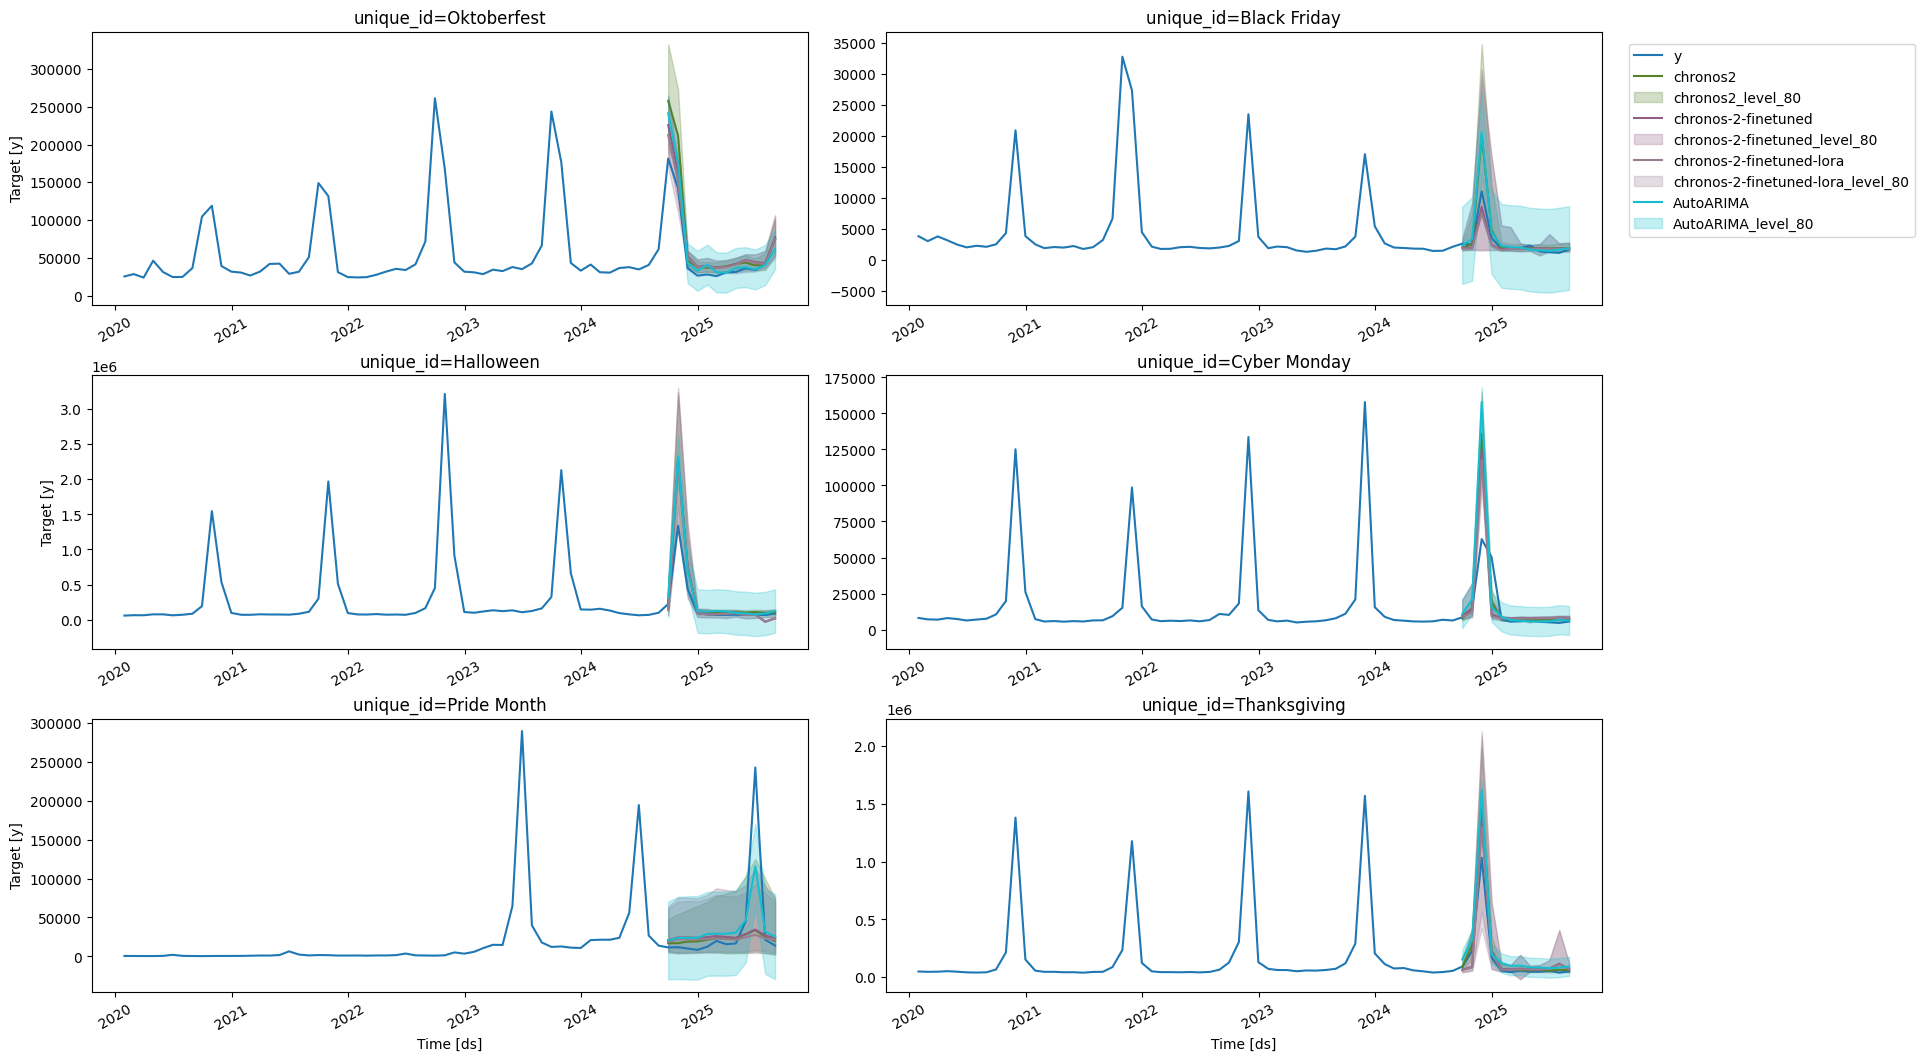

In [4]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])


### Evaluation

In [5]:
eval_compare = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_compare.groupby("metric").mean(numeric_only=True).T.sort_values(by="scaled_crps").round(3)


metric,mase,scaled_crps
chronos-2-finetuned-lora,1.509,0.364
chronos-2-finetuned,1.681,0.389
chronos2,1.705,0.412
AutoARIMA,1.897,0.565


## Using the best model for forecasts

The evaluation showed that **Chronos 2 finetuned with LoRA** had the best (lowest) scaled CRPS among the compared models. Because we saved it with `save_path="./chronos-2-finetuned-lora/"`, we can load it and use it for new forecasts without finetuning again.

In [9]:
best_model_path = "chronos-2-finetuned-lora-path"
best_model = Chronos(
    repo_id=best_model_path,
    finetuning_config=None,
    batch_size=2,
    alias="chronos2-best",
)
fcst_best = best_model.forecast(df, h=12, freq="MS", level=[80, 90])
fcst_best.head()

100%|██████████| 3/3 [00:00<00:00, 18.56it/s]


,unique_id,ds,chronos2-best,chronos2-best-lo-80,chronos2-best-hi-80,chronos2-best-lo-90,chronos2-best-hi-90
0,Black Friday,2025-09-01,1747.354492,1240.749023,2497.809326,1049.929443,3276.111572
1,Black Friday,2025-10-01,2236.327637,1297.549805,6467.433594,1051.353516,8020.196289
2,Black Friday,2025-11-01,12611.657227,5214.403320,22868.658203,3748.068359,27442.648438
3,Black Friday,2025-12-01,3226.313232,1481.221680,8127.299805,1229.192383,10268.513672
4,Black Friday,2026-01-01,1604.315918,1096.437012,2360.342773,894.071777,3173.337891


The forecasts above come from the best-performing model in our comparison (Chronos 2 with LoRA finetuning), loaded from the saved checkpoint. You can reuse this path in other notebooks or scripts for inference without running finetuning again.

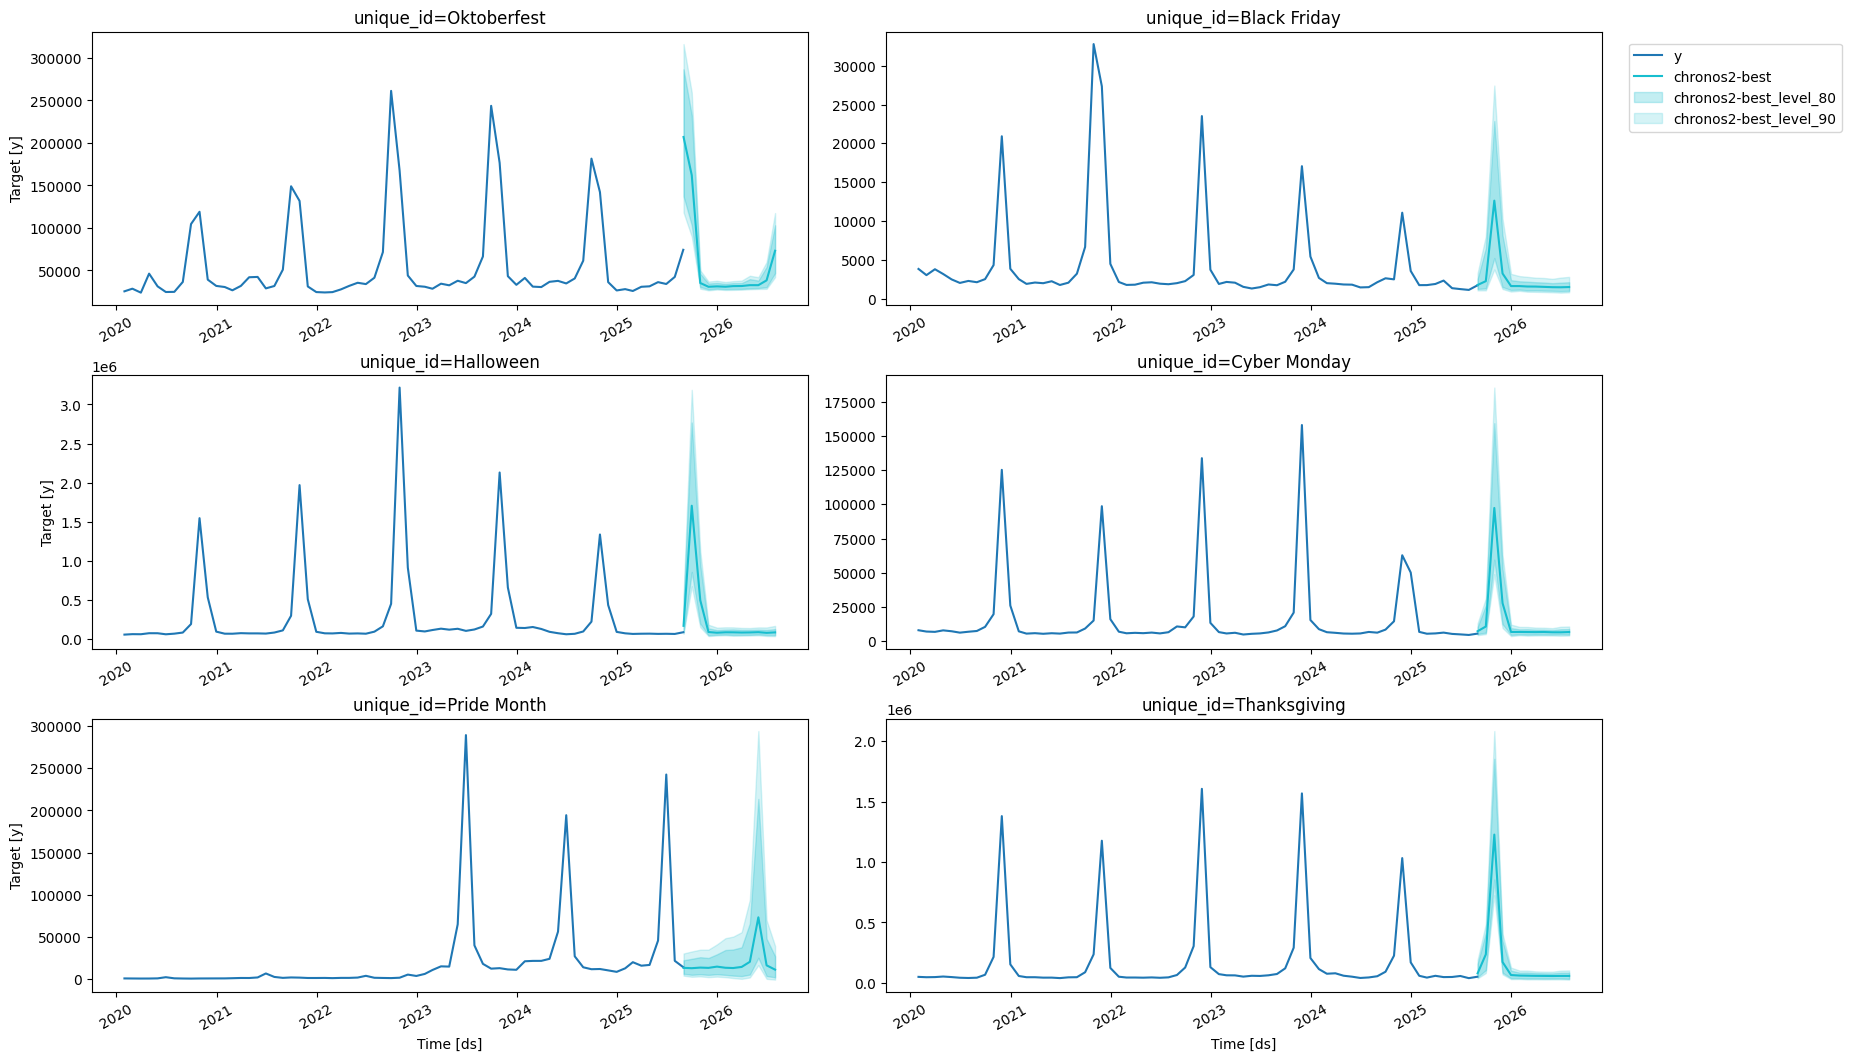

In [10]:
best_model.plot(df, fcst_best, level=[80, 90])